# hCorpus — generador modular de logo

Este notebook construye el logo de **hCorpus** por módulos independientes:

1. Cadena de ADN / datos
2. Isotipo `hC`
3. Molécula / red de nodos
4. Wordmark `hCorpus`
5. Composición final

Cada módulo puede **activarse o desactivarse**, visualizarse por separado y luego ensamblarse en el logo completo.

La idea es que puedas modificar una sección sin tener que rehacer las demás.


In [1]:
# ============================================================
# 00. IMPORTACIONES
# ============================================================

from PIL import Image, ImageDraw, ImageFont
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (10, 7)


In [3]:
# ============================================================
# 01. CONFIGURACIÓN GENERAL
# ============================================================
# Supersampling
S = 3
# Tamaño final
W = 1200
H = 800
# ------------------------------------------------------------
# PALETA CORPORATIVA
# ------------------------------------------------------------
NAVY = (18, 43, 91, 255)
NAVY_DARK = (12, 36, 78, 255)
BLUE = (40, 105, 170, 255)
TEAL = (18, 145, 165, 255)
CYAN = (20, 175, 190, 255)
GRAY = (150, 157, 163, 255)
WHITE = (255, 255, 255, 255)
TRANSPARENT = (255, 255, 255, 0)
# ------------------------------------------------------------
# ACTIVAR / DESACTIVAR MÓDULOS
# ------------------------------------------------------------
MOSTRAR_ADN = True
MOSTRAR_HC = True
MOSTRAR_MOLECULA = True
MOSTRAR_WORDMARK = True
# ------------------------------------------------------------
# POSICIONES
# ------------------------------------------------------------
POS_ADN = (90, 50)
POS_HC = (285, 55)
POS_MOLECULA = (800, 120)
POS_WORDMARK = (285, 540)
# ------------------------------------------------------------
# OPCIONES DE VISUALIZACIÓN
# ------------------------------------------------------------
MOSTRAR_GUIAS = False

In [9]:
# ============================================================
# 02. FUNCIONES GENERALES
# ============================================================

def sc(v):
    return int(round(v * S))


def crear_canvas(ancho=W, alto=H, fondo=TRANSPARENT):
    return Image.new(
        "RGBA",
        (sc(ancho), sc(alto)),
        fondo
    )


def line(draw, x1, y1, x2, y2, fill, width=2):
    draw.line(
        (
            sc(x1),
            sc(y1),
            sc(x2),
            sc(y2)
        ),
        fill=fill,
        width=max(1, sc(width))
    )


def node(draw, x, y, r, fill):
    draw.ellipse(
        (
            sc(x-r),
            sc(y-r),
            sc(x+r),
            sc(y+r)
        ),
        fill=fill
    )


def cargar_fuente(tamano=145):
    rutas = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        "/usr/share/fonts/truetype/liberation2/LiberationSans-Regular.ttf",
        "/Library/Fonts/Arial.ttf",
        "/System/Library/Fonts/Supplemental/Arial.ttf"
    ]

    for ruta in rutas:
        try:
            return ImageFont.truetype(ruta, sc(tamano))
        except OSError:
            continue

    return ImageFont.load_default()


def mostrar_imagen(img, titulo="", figsize=(10, 7), fondo="white"):
    fig, ax = plt.subplots(figsize=figsize)

    if fondo == "white":
        ax.imshow(img)
    else:
        ax.imshow(img)

    ax.set_title(titulo, fontsize=14, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


def reducir(img):
    return img.resize(
        (W, H),
        Image.Resampling.LANCZOS
    )


def mover_y_pegar(base, elemento, posicion):
    x, y = posicion

    base.alpha_composite(
        elemento,
        (sc(x), sc(y))
    )


## Módulo 1 — Cadena de ADN / datos

Este componente es completamente independiente. Aquí puedes modificar la cantidad de líneas, posiciones, colores, longitud y tamaño de los nodos sin tocar los demás módulos.


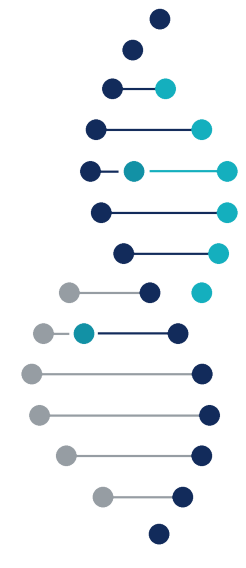

In [11]:
# ============================================================
# 03. MÓDULO ADN / DATOS
# ============================================================
CONFIG_ADN = {
    "ancho": 180,
    "alto": 430,
    "radio_nodo": 8,
    "grosor_linea": 2,
    "separacion": 34,
}
def crear_adn(config=CONFIG_ADN):
    ancho = config["ancho"]
    alto = config["alto"]
    r = config["radio_nodo"]
    grosor = config["grosor_linea"]

    adn = Image.new(
        "RGBA",
        (sc(ancho), sc(alto)),
        TRANSPARENT
    )
    draw = ImageDraw.Draw(adn)
    # (y, x_inicio, x_final, color_izquierdo, color_derecho)
    data_lines = [
        (64.12, 81.39, 122.41, NAVY, CYAN),
        (95.61, 68.73, 150.25, NAVY, CYAN),
        (128.08, 64.18, 86, NAVY, None),
        (128.08, 170, 110, CYAN, None),
        (160.06, 72.78, 170, NAVY, CYAN),
        (191.54, 90, 163.42, NAVY, CYAN),
        (222.05, 48.10, 110.25, GRAY, NAVY),
        (253.53, 28, 48, GRAY, None),
        (253.53, 132.03, 70, NAVY, None),
        (285.02, 19.11, 150.76, GRAY, NAVY),

        (317, 25, 156.33, GRAY, NAVY),
        (348.49, 45.63, 150.25, GRAY, NAVY),

        (380.46, 73.86, 135.57, GRAY, NAVY),
    ]
    for y, x1, x2, c1, c2 in data_lines:
        line(
            draw,
            x1, y,
            x2, y,
            fill=c1,
            width=grosor
        )
        node(
            draw,
            x1, y,
            r,
            c1
        )
        if c2 is not None:
            node(
                draw,
                x2, y,
                r,
                c2
            )
    # Nodos superiores
    node(draw, 117.85, 10, r, NAVY)
    node(draw, 97.09, 34.11, r, NAVY)
    node(draw, 98.10, 128.08, r, TEAL)
    node(draw, 150.25, 222.05, r, CYAN)
    node(draw, 59.37, 253.53, r, TEAL)
    node(draw, 117.34, 409, r, NAVY)

    return adn

#NAVY, NAVY_DARK, BLUE, TEAL, CYAN, GRAY

# Generar
adn = crear_adn()

# Vista individual
mostrar_imagen(
    adn,
    figsize=(4, 8)
)


## Módulo 2 — Isotipo `hC`

La `h` y la `C` se consideran un único módulo visual. La `C` utiliza una máscara para que el degradado se aplique exclusivamente a su forma.


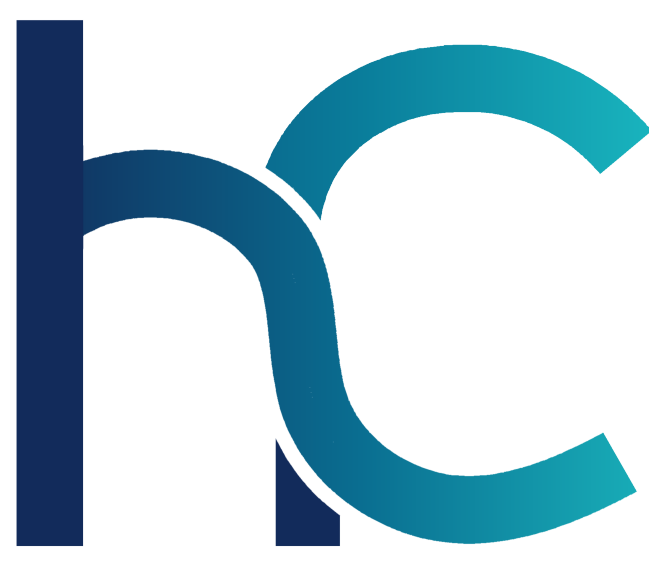

In [21]:
# ============================================================
# 04. MÓDULO HC
# ============================================================
CONFIG_HC = {
    "ancho": 550,"alto": 475,
    # ========================================================
    # BARRA VERTICAL IZQUIERDA
    # ========================================================
    "barra": {"x1": 8,"y1": 12,"x2": 65,"y2": 462,},
    # ========================================================
    # CURVA PRINCIPAL
    # ESTA ES UNA SOLA CURVA CONTINUA.
    # Empieza en la barra izquierda,
    # forma la parte superior,
    # baja,
    # gira hacia la derecha
    # y termina formando la parte inferior.
    # ========================================================
    "curva_principal": {
        "grosor": 58,
        # ----------------------------------------------------
        # Tramo 1 Desde la barra hacia la derecha
        # ----------------------------------------------------
        "p1": (45, 175),
        "c1": (105, 135),
        "c2": (185, 150),
        "p2": (225, 195),
        # ----------------------------------------------------
        # Tramo 2 Bajada vertical curva
        # ----------------------------------------------------
        "c3": (255, 225),
        "c4": (250, 280),
        "p3": (258, 320),
        # ----------------------------------------------------
        # Tramo 3 Curva hacia abajo y derecha
        # ----------------------------------------------------
        "c5": (265, 370),
        "c6": (305, 410),
        "p4": (355, 425),
        # ----------------------------------------------------
        # Tramo 4 Curva inferior
        # ----------------------------------------------------
        "c7": (410, 442),
        "c8": (470, 420),
        "p5": (525, 390),},
    # ========================================================
    # SEGMENTO SUPERIOR
    # Es solamente la parte superior de la C.
    # Está SEPARADO de la curva principal.
    # ========================================================
    "c_superior": {
    "grosor": 58,
    "p1": (240, 180),
    "c1": (250, 105),
    "c2": (315, 65),
    "p2": (380, 62),
    "c3": (435, 58),
    "c4": (490, 78),
    "p3": (530, 125),},
    # ========================================================
    # PATICA INFERIOR
    # NO es un rectángulo.
    # Tiene un corte diagonal.
    # ========================================================
    "patica": [
        (230, 350),
        (230, 462),
        (285, 462),
        (285, 350),
        (255, 350),],}
# ============================================================
# BEZIER CÚBICA
# ============================================================
def bezier_cubica(p0, p1, p2, p3, n=60):
    puntos = []
    for i in range(n + 1):
        t = i / n
        u = 1 - t
        x = (u**3 * p0[0] + 3 * u**2 * t * p1[0] + 3 * u * t**2 * p2[0] + t**3 * p3[0])
        y = (u**3 * p0[1] + 3 * u**2 * t * p1[1] + 3 * u * t**2 * p2[1] + t**3 * p3[1])
        puntos.append((x, y))
    return puntos
# ============================================================
# CONSTRUIR CURVA PRINCIPAL
# ============================================================
def construir_curva_principal(config):
    curvas = config["curva_principal"]
    puntos = []
    # --------------------------------------------------------
    # TRAMO 1
    # --------------------------------------------------------
    puntos.extend(
        bezier_cubica(curvas["p1"],curvas["c1"],curvas["c2"],curvas["p2"],n=70))
    # --------------------------------------------------------
    # TRAMO 2
    # --------------------------------------------------------
    puntos.extend(bezier_cubica(curvas["p2"],curvas["c3"],curvas["c4"],curvas["p3"],n=70)[1:])
    # --------------------------------------------------------
    # TRAMO 3
    # --------------------------------------------------------
    puntos.extend(bezier_cubica(curvas["p3"],curvas["c5"],curvas["c6"],curvas["p4"],n=70)[1:])
    # --------------------------------------------------------
    # TRAMO 4
    # --------------------------------------------------------
    puntos.extend(
        bezier_cubica(curvas["p4"],curvas["c7"],curvas["c8"],curvas["p5"],n=70)[1:])
    return puntos
# ============================================================
# CONSTRUIR C SUPERIOR
# ============================================================
def construir_c_superior(config):
    c = config["c_superior"]
    puntos = []
    puntos.extend(bezier_cubica(c["p1"],c["c1"],c["c2"],c["p2"],n=70))
    puntos.extend(bezier_cubica(c["p2"],c["c3"],c["c4"],c["p3"],n=70)[1:])
    return puntos
# ============================================================
# CREAR GRADIENTE
# ============================================================
def crear_gradiente(ancho,alto,color_inicio,color_medio,color_final):
    gradient = np.zeros((sc(alto), sc(ancho), 4),dtype=np.uint8)
    color_inicio = np.array(color_inicio,dtype=float)
    color_medio = np.array(color_medio,dtype=float)
    color_final = np.array(color_final,dtype=float)
    for x in range(sc(ancho)):
        px = x / S
        # ----------------------------------------------------
        # Inicio → medio
        # ----------------------------------------------------
        if px < 300:
            t = np.clip(px / 300,0,1)
            color = (color_inicio * (1 - t) + color_medio * t)
        # ----------------------------------------------------
        # Medio → final
        # ----------------------------------------------------
        else:
            t = np.clip((px - 300) / 250, 0, 1)
            color = (color_medio * (1 - t) + color_final * t )
        gradient[:, x, :3] = (np.clip(color, 0, 255)
            .astype(np.uint8))
        gradient[:, x, 3] = 255
    return Image.fromarray(gradient,"RGBA")
# ============================================================
# DIBUJAR TRAYECTORIA
# ============================================================
def dibujar_trayectoria(draw,puntos,width,fill):
    puntos_sc = [(sc(x),sc(y))
        for x, y in puntos]
    draw.line(puntos_sc,fill=fill,width=sc(width),joint="curve")
# ============================================================
# CREAR HC
# ============================================================
def crear_hc(config=CONFIG_HC):
    ancho = config["ancho"]
    alto = config["alto"]
    hc = Image.new("RGBA",(sc(ancho), sc(alto)),TRANSPARENT)
    draw = ImageDraw.Draw(hc)
    # ========================================================
    # 2. C SUPERIOR
    # ========================================================
    puntos_c = construir_c_superior(config)
    # --------------------------------------------------------
    # MÁSCARA C
    # --------------------------------------------------------
    mask_c = Image.new("L",hc.size,0)
    draw_c = ImageDraw.Draw(mask_c)
    dibujar_trayectoria(draw_c,puntos_c,config["c_superior"]["grosor"],255)
    # --------------------------------------------------------
    # GRADIENTE C
    # --------------------------------------------------------
    gradient_c = crear_gradiente(ancho,alto,(10, 65, 115),(10, 125, 155),(25, 180, 190))
    hc.paste(gradient_c,(0, 0),mask_c)
    # ========================================================
    # 4. PATICA
    # ========================================================
    patica = [(sc(x), sc(y))
        for x, y in config["patica"]]
    draw = ImageDraw.Draw(hc)
    draw.polygon(patica,fill=NAVY)
    # ========================================================
    # 1. CURVA PRINCIPAL
    # ========================================================
    puntos_principal = construir_curva_principal(config)
    # --------------------------------------------------------
    # MÁSCARA BLANCA DE LA CURVA PRINCIPAL
    # --------------------------------------------------------
    mask_principal_blanca = Image.new("L",hc.size,0)
    draw_principal_blanca = ImageDraw.Draw(mask_principal_blanca)
    # Grosor ligeramente mayor para crear el borde
    # blanco alrededor de la curva principal.
    dibujar_trayectoria(draw_principal_blanca,puntos_principal,
        config["curva_principal"]["grosor"] + 25,255)
    # --------------------------------------------------------
    # CAPA BLANCA
    # --------------------------------------------------------
    white_layer = Image.new("RGBA",hc.size, (255, 255, 255, 255))
    hc.paste(white_layer,(0, 0),mask_principal_blanca)
    # ========================================================
    # CURVA PRINCIPAL REAL
    # ========================================================
    mask_principal = Image.new("L",hc.size,0)
    draw_mask = ImageDraw.Draw(mask_principal)
    dibujar_trayectoria(draw_mask,puntos_principal,config["curva_principal"]["grosor"],255)
    # --------------------------------------------------------
    # GRADIENTE CURVA PRINCIPAL
    # --------------------------------------------------------
    gradient_principal = crear_gradiente(ancho,alto,(18, 43, 91),(10, 110, 145),(25, 175, 185))
    hc.paste(gradient_principal,(0, 0),mask_principal)
    # ========================================================
    # 3. BARRA VERTICAL
    # ========================================================
    barra = config["barra"]
    draw.rectangle((sc(barra["x1"]),sc(barra["y1"]),sc(barra["x2"]),sc(barra["y2"])),fill=NAVY)
    return hc
# ============================================================
# GENERAR
# ============================================================
hc = crear_hc()
# ============================================================
# VISTA
# ============================================================
mostrar_imagen(hc,figsize=(10, 8))

## Módulo 3 — Molécula / red de datos

La molécula también está aislada. Los nodos y conexiones se pueden modificar de manera independiente.


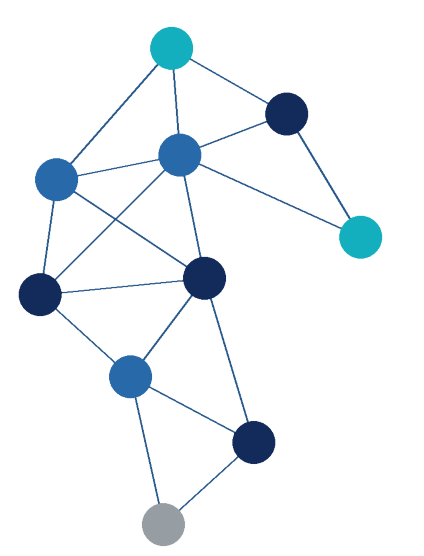

In [13]:
# ============================================================
# 05. MÓDULO MOLÉCULA
# ============================================================
CONFIG_MOLECULA = {"ancho": 250,"alto": 330,"radio_nodo": 13,"grosor_linea": 1.5,}
def crear_molecula(config=CONFIG_MOLECULA):
    ancho = config["ancho"]
    alto = config["alto"]
    r = config["radio_nodo"]
    grosor = config["grosor_linea"]
    molecula = Image.new("RGBA",(sc(ancho), sc(alto)),TRANSPARENT)
    draw = ImageDraw.Draw(molecula)
    # --------------------------------------------------------
    # NODOS
    # --------------------------------------------------------
    nodes = {
        1: (100, 25, CYAN),
        2: (170, 65, NAVY),
        3: (30, 105, BLUE),
        4: (105, 90, BLUE),
        5: (215, 140, CYAN),
        6: (20, 175, NAVY),
        7: (120, 165, NAVY),
        8: (75, 225, BLUE),
        9: (150, 265, NAVY),
        10: (95, 315, GRAY)
    }
    # --------------------------------------------------------
    # CONEXIONES
    # --------------------------------------------------------
    connections = [
        (1, 2),
        (1, 3),
        (1, 4),
        (2, 4),
        (2, 5),
        (3, 4),
        (3, 6),
        (3, 7),
        (4, 6),
        (4, 7),
        (4, 5),
        (6, 7),
        (6, 8),
        (7, 8),
        (7, 9),
        (8, 9),
        (8, 10),
        (9, 10)
    ]
    # Líneas primero
    for a, b in connections:
        x1, y1, _ = nodes[a]
        x2, y2, _ = nodes[b]
        line(draw,x1,y1,x2,y2,fill=(38, 88, 140, 255),width=grosor)
    # Nodos después
    for x, y, color in nodes.values():
        node(draw,x,y,r,color)
    return molecula
# Generar
molecula = crear_molecula()
# Vista individual
mostrar_imagen(molecula,figsize=(6, 8))


## Módulo 4 — Wordmark `hCorpus`

El texto se mantiene separado del isotipo. Así puedes cambiar fuente, tamaño, posición o incluso sustituir el texto sin modificar ninguna otra pieza.


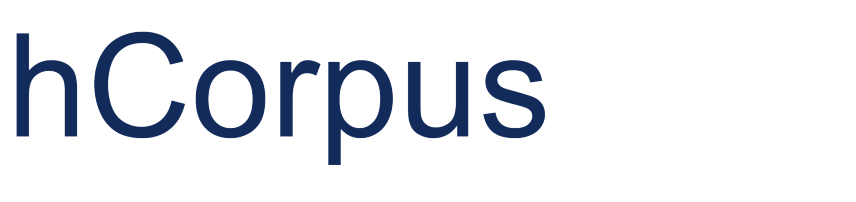

In [15]:
# ============================================================
# 04. MÓDULO WORDMARK
# ============================================================
CONFIG_WORDMARK = {"ancho": 850,"alto": 190,"texto": "hCorpus","tamano": 145,"x": 0,"y": 0,}
def crear_wordmark(config=CONFIG_WORDMARK):
    ancho = config["ancho"]
    alto = config["alto"]
    wordmark = Image.new("RGBA",(sc(ancho), sc(alto)),TRANSPARENT)
    draw = ImageDraw.Draw(wordmark)
    fuente = cargar_fuente(config["tamano"])
    draw.text((sc(config["x"]),sc(config["y"])),config["texto"],font=fuente,fill=NAVY)
    return wordmark
# Generar
wordmark = crear_wordmark()
# Vista individual
mostrar_imagen(wordmark,figsize=(12, 4))

## Módulo 5 — Composición

Aquí no se dibuja ningún elemento nuevo. Únicamente se toman los cuatro módulos y se colocan en el lienzo final.

Esto permite activar/desactivar cualquier módulo desde la configuración.


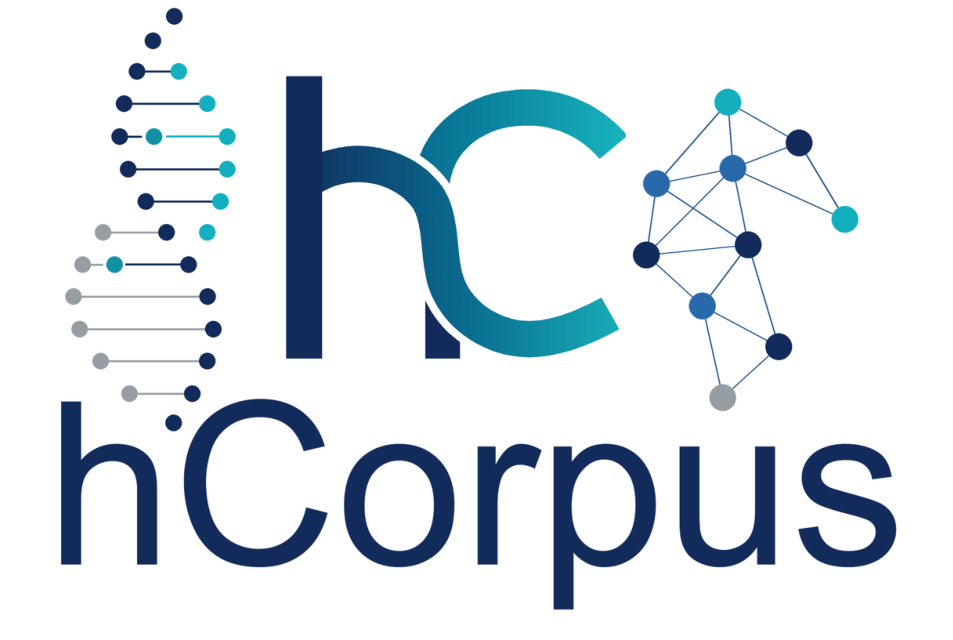

In [23]:
# ============================================================
# 07. COMPOSICIÓN FINAL
# ============================================================
# ============================================================
# ESCALAS DE CADA ELEMENTO
# ============================================================
ESCALA_ADN = 1.30
ESCALA_HC = 0.80
ESCALA_MOLECULA = 1.30
ESCALA_WORDMARK = 2.00
# ============================================================
# POSICIONES
# ============================================================
POS_ADN = (60,0)
POS_HC = (350, 80)
POS_MOLECULA = (790, 90)
POS_WORDMARK = (50, 450)
# ============================================================
# REDIMENSIONAR MANTENIENDO PROPORCIÓN
# ============================================================
def escalar_imagen(imagen, escala):
    if escala == 1:
        return imagen
    ancho = int(imagen.width * escala)
    alto = int(imagen.height * escala)
    return imagen.resize((ancho, alto),Image.Resampling.LANCZOS)
# ============================================================
# COMPOSICIÓN FINAL
# ============================================================
def componer_logo():
    canvas = crear_canvas(W,H,WHITE)
    # ========================================================
    # ADN
    # ========================================================
    if MOSTRAR_ADN:
        adn_final = escalar_imagen(adn,ESCALA_ADN)
        mover_y_pegar(canvas,adn_final,POS_ADN)
    # ========================================================
    # HC
    # ========================================================
    if MOSTRAR_HC:
        hc_final = escalar_imagen(hc,ESCALA_HC)
        mover_y_pegar(canvas,hc_final,POS_HC)
    # ========================================================
    # MOLÉCULA
    # ========================================================
    if MOSTRAR_MOLECULA:
        molecula_final = escalar_imagen(molecula,ESCALA_MOLECULA)
        mover_y_pegar(canvas,molecula_final,POS_MOLECULA)
    # ========================================================
    # WORDMARK
    # ========================================================
    if MOSTRAR_WORDMARK:
        wordmark_final = escalar_imagen(wordmark,ESCALA_WORDMARK)
        mover_y_pegar(canvas,wordmark_final,POS_WORDMARK)
    return reducir(canvas)
# ============================================================
# GENERAR
# ============================================================
logo = componer_logo()
# ============================================================
# 08. PREVIEW DEL LOGO COMPLETO
# ============================================================
mostrar_imagen(logo,figsize=(14, 9))

## Control de módulos

Puedes probar diferentes composiciones simplemente cambiando `True` / `False`.

### Solo isotipo

```python
MOSTRAR_ADN = False
MOSTRAR_HC = True
MOSTRAR_MOLECULA = True
MOSTRAR_WORDMARK = False
```

### Solo `hC`

```python
MOSTRAR_ADN = False
MOSTRAR_HC = True
MOSTRAR_MOLECULA = False
MOSTRAR_WORDMARK = False
```

### Logo completo

```python
MOSTRAR_ADN = True
MOSTRAR_HC = True
MOSTRAR_MOLECULA = True
MOSTRAR_WORDMARK = True
```

Después de cambiar estas opciones, vuelve a ejecutar la celda de composición y la celda de preview.


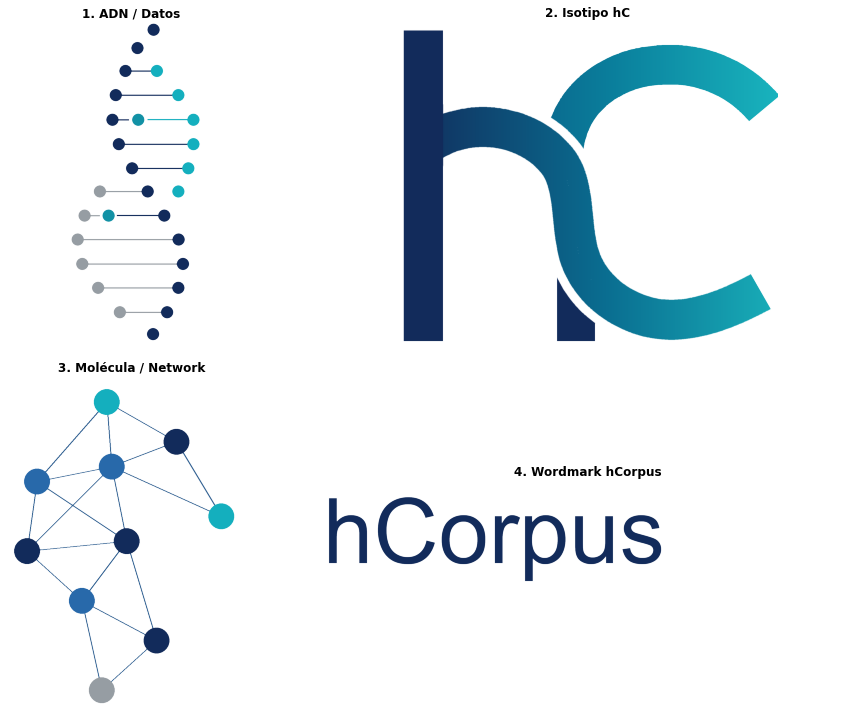

In [25]:
# ============================================================
# 09. PREVIEW INDIVIDUAL DE TODOS LOS MÓDULOS
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10)
)

axes[0, 0].imshow(adn)
axes[0, 0].set_title("1. ADN / Datos", fontweight="bold")
axes[0, 0].axis("off")

axes[0, 1].imshow(hc)
axes[0, 1].set_title("2. Isotipo hC", fontweight="bold")
axes[0, 1].axis("off")

axes[1, 0].imshow(molecula)
axes[1, 0].set_title("3. Molécula / Network", fontweight="bold")
axes[1, 0].axis("off")

axes[1, 1].imshow(wordmark)
axes[1, 1].set_title("4. Wordmark hCorpus", fontweight="bold")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


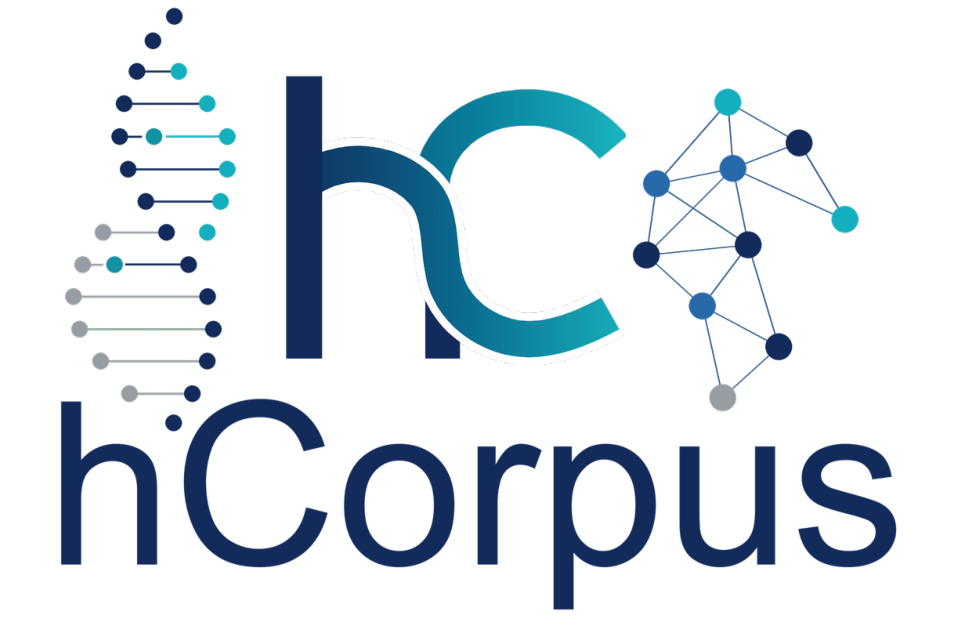

In [27]:
# ============================================================
# 09B. COMPOSICIÓN TRANSPARENTE PARA EXPORTACIÓN
# ============================================================
def componer_logo_transparente():
    canvas = crear_canvas(W,H,TRANSPARENT)
    # ========================================================
    # ADN
    # ========================================================
    if MOSTRAR_ADN:
        adn_final = escalar_imagen(adn,ESCALA_ADN)
        mover_y_pegar(canvas,adn_final,POS_ADN)
    # ========================================================
    # HC
    # ========================================================
    if MOSTRAR_HC:
        hc_final = escalar_imagen(hc,ESCALA_HC)
        mover_y_pegar(canvas,hc_final,POS_HC)
    # ========================================================
    # MOLÉCULA
    # ========================================================
    if MOSTRAR_MOLECULA:
        molecula_final = escalar_imagen(molecula,ESCALA_MOLECULA)
        mover_y_pegar(canvas,molecula_final,POS_MOLECULA)
    # ========================================================
    # WORDMARK
    # ========================================================
    if MOSTRAR_WORDMARK:
        wordmark_final = escalar_imagen(wordmark,ESCALA_WORDMARK)
        mover_y_pegar(canvas,wordmark_final,POS_WORDMARK)
    return reducir(canvas)
# ============================================================
# PREVIEW TRANSPARENTE
# ============================================================
logo_transparente_preview = (componer_logo_transparente())
mostrar_imagen(logo_transparente_preview,figsize=(14, 9))

In [29]:
import io
import base64

In [31]:
# ============================================================
# 10. EXPORTACIÓN
# ============================================================
EXPORTAR = True
CARPETA_SALIDA = Path("hCorpus_export")
CARPETA_SALIDA.mkdir(exist_ok=True)
# ============================================================
# FUNCIÓN PARA CREAR SVG
# ============================================================
def guardar_svg_desde_png(imagen,ruta_svg):
    # --------------------------------------------------------
    # Convertir imagen RGBA a PNG en memoria
    # --------------------------------------------------------
    buffer = io.BytesIO()
    imagen.save(buffer,format="PNG")
    png_base64 = base64.b64encode(buffer.getvalue()).decode("utf-8")
    # --------------------------------------------------------
    # SVG
    # --------------------------------------------------------
    svg = f'''<?xml version="1.0" encoding="UTF-8"?>
<svg
    xmlns="http://www.w3.org/2000/svg"
    xmlns:xlink="http://www.w3.org/1999/xlink"
    width="{imagen.width}"
    height="{imagen.height}"
    viewBox="0 0 {imagen.width} {imagen.height}"
>
    <image
        width="{imagen.width}"
        height="{imagen.height}"
        x="0"
        y="0"
        href="data:image/png;base64,{png_base64}"
    />
</svg>
'''
    with open(
        ruta_svg,
        "w",
        encoding="utf-8"
    ) as f:
        f.write(svg)
# ============================================================
# EXPORTAR
# ============================================================
if EXPORTAR:
    # ========================================================
    # PNG FONDO BLANCO
    # ========================================================
    logo.convert("RGB").save(CARPETA_SALIDA / "hCorpus_logo.png",dpi=(300, 300))
    # ========================================================
    # JPG
    # ========================================================
    logo.convert("RGB").save(CARPETA_SALIDA / "hCorpus_logo.jpg",quality=98,dpi=(300, 300))
    # ========================================================
    # PNG TRANSPARENTE
    # ========================================================
    logo_transparente = (componer_logo_transparente())
    logo_transparente.save(CARPETA_SALIDA / "hCorpus_logo_transparente.png",dpi=(300, 300))
    # ========================================================
    # SVG TRANSPARENTE
    # ========================================================
    guardar_svg_desde_png(logo_transparente,CARPETA_SALIDA / "hCorpus_logo_transparente.svg")
    # ========================================================
    # SVG CON FONDO BLANCO
    # ========================================================
    guardar_svg_desde_png(logo,CARPETA_SALIDA / "hCorpus_logo.svg")
    print(f"Archivos exportados en:\n"
        f"{CARPETA_SALIDA.resolve()}")
else:
    print(
        "EXPORTAR = False → "
        "no se han creado archivos.")

Archivos exportados en:
/Users/cahuertasc/Documents/hCorpus/hCorpus_export


## Flujo recomendado de trabajo

1. Modifica un módulo.
2. Ejecuta su celda.
3. Revisa la visualización individual.
4. Ajusta parámetros.
5. Ejecuta la composición.
6. Revisa el logo completo.
7. Activa `EXPORTAR = True` únicamente cuando estés conforme.

Para agregar un quinto módulo en el futuro, solo necesitas crear otra función `crear_...()`, generar el objeto y añadirlo a `componer_logo()`. El resto del sistema permanece igual.


---

## Módulo 6 — Correcciones detectadas al generar los formatos

Al sacar las versiones aparecieron tres fallos que no se ven en el preview grande:

1. **El wordmark se recortaba.** Su lienzo era fijo (850×190) y el texto se salía. Ahora el lienzo se calcula midiendo el texto.
2. **El isotipo solo servía sobre blanco.** El halo que separa la `h` de la `C` estaba fijo en blanco, así que sobre fondo azul aparecía un contorno blanco y la `h` desaparecía. Ahora el halo y el color de la `h` son parámetros, y existe una variante calada para fondos oscuros.
3. **La composición recortaba en silencio.** Con `W = 1200` y `ESCALA_WORDMARK = 2.0`, el wordmark mide 1250 y se perdía la `s` final sin lanzar ningún error. Ahora el lienzo crece si alguna pieza se sale.

Ejecute esta celda **después** de las celdas de los módulos y **antes** de la de formatos.

In [33]:
# ============================================================
# 10B. CORRECCIONES A LOS MÓDULOS
# ============================================================
# Dos problemas que solo aparecen al generar los formatos:
#   1. El wordmark se recorta: el lienzo es fijo (850x190) y el
#      texto se sale. Ahora el lienzo se calcula a partir del texto.
#   2. El isotipo lleva un halo blanco fijo entre la h y la C, así
#      que solo funciona sobre blanco. Ahora el halo y el color de
#      la h son parámetros, para poder sacar la versión clara.
# ============================================================

def crear_wordmark(config=CONFIG_WORDMARK):
    """El lienzo se ajusta al texto: ya no se recorta la 's' final."""
    fuente = cargar_fuente(config["tamano"])
    medidor = ImageDraw.Draw(Image.new("RGBA", (10, 10)))
    x0, y0, x1, y1 = medidor.textbbox((0, 0), config["texto"], font=fuente)
    m = sc(12)                                    # aire alrededor
    wordmark = Image.new("RGBA", (x1 - x0 + 2*m, y1 - y0 + 2*m), TRANSPARENT)
    ImageDraw.Draw(wordmark).text(
        (m - x0, m - y0),
        config["texto"],
        font=fuente,
        fill=config.get("color", NAVY))
    return wordmark


CONFIG_HC["color_h"] = NAVY            # barra vertical y patica
CONFIG_HC["color_separador"] = WHITE   # halo entre la h y la C
                                       # usar TRANSPARENT para versión calada


def crear_hc(config=CONFIG_HC):
    ancho, alto = config["ancho"], config["alto"]
    color_h = config.get("color_h", NAVY)
    color_sep = config.get("color_separador", WHITE)

    hc = Image.new("RGBA", (sc(ancho), sc(alto)), TRANSPARENT)
    draw = ImageDraw.Draw(hc)

    # --- C superior con degradado ---------------------------
    puntos_c = construir_c_superior(config)
    mask_c = Image.new("L", hc.size, 0)
    dibujar_trayectoria(ImageDraw.Draw(mask_c), puntos_c,
                        config["c_superior"]["grosor"], 255)
    hc.paste(crear_gradiente(ancho, alto, (10, 65, 115), (10, 125, 155), (25, 180, 190)),
             (0, 0), mask_c)

    # --- patica ---------------------------------------------
    ImageDraw.Draw(hc).polygon([(sc(x), sc(y)) for x, y in config["patica"]],
                               fill=color_h)

    # --- separador (halo) -----------------------------------
    puntos_principal = construir_curva_principal(config)
    mask_halo = Image.new("L", hc.size, 0)
    dibujar_trayectoria(ImageDraw.Draw(mask_halo), puntos_principal,
                        config["curva_principal"]["grosor"] + 25, 255)
    hc.paste(Image.new("RGBA", hc.size, color_sep), (0, 0), mask_halo)

    # --- curva principal ------------------------------------
    mask_principal = Image.new("L", hc.size, 0)
    dibujar_trayectoria(ImageDraw.Draw(mask_principal), puntos_principal,
                        config["curva_principal"]["grosor"], 255)
    hc.paste(crear_gradiente(ancho, alto, (18, 43, 91), (10, 110, 145), (25, 175, 185)),
             (0, 0), mask_principal)

    # --- barra vertical -------------------------------------
    b = config["barra"]
    ImageDraw.Draw(hc).rectangle(
        (sc(b["x1"]), sc(b["y1"]), sc(b["x2"]), sc(b["y2"])), fill=color_h)
    return hc


# --- Regenerar los módulos con las correcciones -------------
wordmark = crear_wordmark()
hc = crear_hc()

# --- Variante para fondos oscuros ---------------------------
# Halo calado (deja ver el fondo) y h en blanco.
hc_claro = crear_hc({**CONFIG_HC,
                     "color_separador": TRANSPARENT,
                     "color_h": WHITE})
wordmark_claro = crear_wordmark({**CONFIG_WORDMARK, "color": WHITE})

print("wordmark:", wordmark.size, "| hc:", hc.size)


wordmark: (1717, 475) | hc: (1650, 1425)


## Módulo 7 — Generación de formatos

Produce las 42 piezas que se necesitan en la práctica: archivos maestros, versiones a una tinta, avatares circulares, favicons, banners y firma de correo.

Dos criterios de diseño del módulo:

- **El avatar nunca es un recorte del logo completo.** Un recorte circular del lockup corta el nombre por la mitad. Los avatares se generan a partir del isotipo aislado.
- **Todo sale del maestro en alta resolución** (supersampling ×3) y se reduce con LANCZOS a cada tamaño final, en vez de reescalar una imagen ya reducida.

Al final se generan dos hojas `PRUEBA_reduccion_*.png` con el logo a 32, 64, 120, 200 y 400 px. Es el control de calidad: si a 64 px una pieza no se distingue, esa pieza no sirve como avatar.

In [35]:
# ============================================================
# 11. GENERADOR DE FORMATOS
# ============================================================
# Produce todas las versiones del logo a partir de los módulos
# ya construidos. No dibuja nada nuevo: recompone, recorta,
# recolorea y encaja en los tamaños de cada plataforma.
# ============================================================

from PIL import Image, ImageDraw

CARPETA_FORMATOS = Path("hCorpus_formatos")
CARPETA_FORMATOS.mkdir(exist_ok=True)

SKY = (110, 205, 210, 255)      # turquesa claro, para fondos oscuros

# ------------------------------------------------------------
# 11.1 COMPOSICIÓN PARAMETRIZADA
# ------------------------------------------------------------
def componer_raw(adn_on=True, hc_on=True, mol_on=True, wm_on=True,
                 fondo=TRANSPARENT, claro=False):
    """
    Igual que componer_logo(), pero:
      - recibe los módulos como argumentos,
      - devuelve el lienzo a resolución de supersampling (sin reducir),
      - y AGRANDA el lienzo si alguna pieza se sale.

    Ese último punto importa: con W=1200 el wordmark a escala 2.0 mide
    1250 y se recortaba la "s" sin dar ningún error.
    """
    piezas = []
    if adn_on:
        piezas.append((escalar_imagen(adn, ESCALA_ADN), POS_ADN))
    if hc_on:
        piezas.append((escalar_imagen(hc_claro if claro else hc, ESCALA_HC), POS_HC))
    if mol_on:
        piezas.append((escalar_imagen(molecula, ESCALA_MOLECULA), POS_MOLECULA))
    if wm_on:
        piezas.append((escalar_imagen(wordmark_claro if claro else wordmark,
                                      ESCALA_WORDMARK), POS_WORDMARK))
    if not piezas:
        return crear_canvas(W, H, fondo)

    ancho_px = max(max(sc(x) + im.width for im, (x, y) in piezas), sc(W))
    alto_px  = max(max(sc(y) + im.height for im, (x, y) in piezas), sc(H))
    canvas = Image.new("RGBA", (ancho_px, alto_px), fondo)
    for im, (x, y) in piezas:
        canvas.alpha_composite(im, (sc(x), sc(y)))
    return canvas

# ------------------------------------------------------------
# 11.2 UTILIDADES DE IMAGEN
# ------------------------------------------------------------
def recortar(img, margen=0.04):
    """Elimina el aire transparente sobrante y deja un margen proporcional."""
    caja = img.getbbox()
    if caja is None:
        return img
    img = img.crop(caja)
    m = int(round(max(img.size) * margen))
    if m == 0:
        return img
    lienzo = Image.new("RGBA", (img.width + 2*m, img.height + 2*m), TRANSPARENT)
    lienzo.alpha_composite(img, (m, m))
    return lienzo

def ancho_a(img, ancho):
    """Redimensiona por ancho, manteniendo la proporción."""
    alto = max(1, round(img.height * ancho / img.width))
    return img.resize((ancho, alto), Image.Resampling.LANCZOS)

def sobre_fondo(img, color=WHITE):
    """Aplana la imagen sobre un color sólido."""
    base = Image.new("RGBA", img.size, color)
    base.alpha_composite(img)
    return base

def una_tinta(img, color):
    """
    Convierte todo el logo a un solo color, conservando la silueta.
    Necesario para grabado, bordado, sellos e impresión a una tinta.
    """
    solido = Image.new("RGBA", img.size, color)
    solido.putalpha(img.getchannel("A"))
    return solido

def encajar(img, ancho, alto, fondo=TRANSPARENT, margen=0.14):
    """Centra el logo dentro de un lienzo de tamaño exacto."""
    disp_w = ancho * (1 - 2*margen)
    disp_h = alto * (1 - 2*margen)
    k = min(disp_w / img.width, disp_h / img.height)
    esc = img.resize((max(1, round(img.width*k)), max(1, round(img.height*k))),
                     Image.Resampling.LANCZOS)
    lienzo = Image.new("RGBA", (ancho, alto), fondo)
    lienzo.alpha_composite(esc, ((ancho - esc.width)//2, (alto - esc.height)//2))
    return lienzo

def circular(img, lado, fondo=NAVY, margen=0.20):
    """Avatar circular: LinkedIn e Instagram recortan en círculo."""
    disco = Image.new("RGBA", (lado, lado), TRANSPARENT)
    ImageDraw.Draw(disco).ellipse((0, 0, lado-1, lado-1), fill=fondo)
    disco.alpha_composite(encajar(img, lado, lado, TRANSPARENT, margen))
    return disco

def cuadrado_redondeado(img, lado, fondo=NAVY, margen=0.20, radio=0.20):
    """Versión para favicon y para apps que no recortan en círculo."""
    base = Image.new("RGBA", (lado, lado), TRANSPARENT)
    ImageDraw.Draw(base).rounded_rectangle(
        (0, 0, lado-1, lado-1), radius=int(lado*radio), fill=fondo)
    base.alpha_composite(encajar(img, lado, lado, TRANSPARENT, margen))
    return base

# ------------------------------------------------------------
# 11.3 COMPOSICIONES ALTERNATIVAS
# ------------------------------------------------------------
def componer_horizontal(separacion=0.10, prop_wordmark=0.55, tinta=None, claro=False):
    """
    Isotipo a la izquierda y wordmark a la derecha.
    Es la versión que se usa en membretes, firmas de correo y banners,
    donde no hay altura para el lockup vertical.
    """
    iso = recortar(componer_raw(False, True, False, False, claro=claro), 0.02)
    wm  = recortar(componer_raw(False, False, False, True, claro=claro), 0.02)
    if tinta:
        iso, wm = una_tinta(iso, tinta), una_tinta(wm, tinta)

    alto_wm = round(iso.height * prop_wordmark)
    wm = ancho_a(wm, max(1, round(wm.width * alto_wm / wm.height)))

    sep = round(iso.width * separacion)
    ancho = iso.width + sep + wm.width
    alto = max(iso.height, wm.height)
    lienzo = Image.new("RGBA", (ancho, alto), TRANSPARENT)
    lienzo.alpha_composite(iso, (0, (alto - iso.height)//2))
    lienzo.alpha_composite(wm, (iso.width + sep, (alto - wm.height)//2))
    return recortar(lienzo, 0.02)

def componer_banner(ancho, alto, fondo=NAVY, margen=0.16):
    """Banner de perfil: usa la variante clara, no una silueta a una tinta."""
    return encajar(componer_horizontal(claro=True), ancho, alto, fondo, margen)

# ------------------------------------------------------------
# 11.4 PIEZAS BASE
# ------------------------------------------------------------
PIEZAS = {
    # nombre                        adn    hc     mol    wm
    "logo-completo":               (True,  True,  True,  True),
    "marca-sin-nombre":            (True,  True,  True,  False),
    "isotipo-hc":                  (False, True,  False, False),
    "wordmark":                    (False, False, False, True),
}

base = {n: recortar(componer_raw(*flags), 0.03) for n, flags in PIEZAS.items()}
base["logo-horizontal"] = componer_horizontal()

# versiones para fondo oscuro
claro = {
    "isotipo-hc":      recortar(componer_raw(False, True, False, False, claro=True), 0.03),
    "logo-completo":   recortar(componer_raw(True, True, True, True, claro=True), 0.03),
    "logo-horizontal": componer_horizontal(claro=True),
}

# ------------------------------------------------------------
# 11.5 EXPORTAR
# ------------------------------------------------------------
def guardar(img, nombre, dpi=(300, 300)):
    ruta = CARPETA_FORMATOS / nombre
    if nombre.lower().endswith((".jpg", ".jpeg")):
        sobre_fondo(img, WHITE).convert("RGB").save(ruta, quality=95, dpi=dpi)
    else:
        img.save(ruta, dpi=dpi)
    return ruta

ANCHO_MAESTRO = 3000        # resolución del archivo maestro

generados = []

# --- 1. Piezas base: transparente, fondo blanco y JPG ---------
for nombre, img in base.items():
    maestro = ancho_a(img, ANCHO_MAESTRO)
    generados += [
        guardar(maestro, f"{nombre}_transparente.png"),
        guardar(sobre_fondo(maestro, WHITE), f"{nombre}_blanco.png"),
        guardar(maestro, f"{nombre}.jpg"),
    ]

# --- 2. Versiones a una tinta ---------------------------------
for nombre in ["logo-completo", "isotipo-hc", "logo-horizontal"]:
    m = ancho_a(base[nombre], ANCHO_MAESTRO)
    generados += [
        guardar(una_tinta(m, NAVY),  f"{nombre}_una-tinta-navy.png"),
        guardar(una_tinta(m, (0,0,0,255)), f"{nombre}_una-tinta-negro.png"),
        guardar(una_tinta(m, WHITE), f"{nombre}_una-tinta-blanco.png"),
    ]

# --- 3. Avatares (el isotipo, nunca un recorte del lockup) -----
for lado, etiqueta in [(1024, "1024"), (400, "400"), (320, "instagram-320"),
                       (300, "linkedin-300")]:
    generados.append(guardar(circular(claro["isotipo-hc"], lado, NAVY),
                             f"avatar-circular_{etiqueta}.png"))
generados.append(guardar(circular(base["isotipo-hc"], 1024, WHITE),
                         "avatar-circular_fondo-blanco_1024.png"))

# versiones sobre fondo oscuro, listas para usar
for nombre, img in claro.items():
    generados.append(guardar(ancho_a(img, ANCHO_MAESTRO), f"{nombre}_para-fondo-oscuro.png"))

# --- 4. Favicons ----------------------------------------------
for lado in [512, 180, 64, 32]:
    generados.append(guardar(cuadrado_redondeado(claro["isotipo-hc"], lado, NAVY),
                             f"favicon_{lado}.png"))

# --- 5. Banners y firma ---------------------------------------
generados += [
    guardar(componer_banner(1584, 396), "banner-linkedin-personal_1584x396.png"),
    guardar(componer_banner(1128, 191), "banner-linkedin-empresa_1128x191.png"),
    guardar(componer_banner(1500, 500), "banner-x-twitter_1500x500.png"),
    guardar(encajar(base["logo-horizontal"], 780, 200, TRANSPARENT, 0.10),
            "firma-correo_780x200.png"),
]

# --- 6. Prueba de reducción (control de calidad) ---------------
def prueba_reduccion(img, tamanos=(32, 64, 120, 200, 400)):
    """
    Renderiza el logo a los tamaños reales de uso.
    Si a 64 px no se distingue, esa pieza no sirve como avatar.
    """
    tiras = [ancho_a(sobre_fondo(img, WHITE), t) for t in tamanos]
    ancho = max(t.width for t in tiras) + 20
    alto = sum(t.height for t in tiras) + 20*len(tiras)
    hoja = Image.new("RGBA", (ancho, alto), WHITE)
    y = 10
    for t in tiras:
        hoja.alpha_composite(t, (10, y)); y += t.height + 20
    return hoja

generados.append(guardar(prueba_reduccion(base["logo-completo"]),
                         "PRUEBA_reduccion_logo-completo.png"))
generados.append(guardar(prueba_reduccion(base["isotipo-hc"]),
                         "PRUEBA_reduccion_isotipo.png"))

print(f"{len(generados)} archivos generados en: {CARPETA_FORMATOS.resolve()}")
for g in sorted(generados):
    print("  ", g.name)


42 archivos generados en: /Users/cahuertasc/Documents/hCorpus/hCorpus_formatos
   PRUEBA_reduccion_isotipo.png
   PRUEBA_reduccion_logo-completo.png
   avatar-circular_1024.png
   avatar-circular_400.png
   avatar-circular_fondo-blanco_1024.png
   avatar-circular_instagram-320.png
   avatar-circular_linkedin-300.png
   banner-linkedin-empresa_1128x191.png
   banner-linkedin-personal_1584x396.png
   banner-x-twitter_1500x500.png
   favicon_180.png
   favicon_32.png
   favicon_512.png
   favicon_64.png
   firma-correo_780x200.png
   isotipo-hc.jpg
   isotipo-hc_blanco.png
   isotipo-hc_para-fondo-oscuro.png
   isotipo-hc_transparente.png
   isotipo-hc_una-tinta-blanco.png
   isotipo-hc_una-tinta-navy.png
   isotipo-hc_una-tinta-negro.png
   logo-completo.jpg
   logo-completo_blanco.png
   logo-completo_para-fondo-oscuro.png
   logo-completo_transparente.png
   logo-completo_una-tinta-blanco.png
   logo-completo_una-tinta-navy.png
   logo-completo_una-tinta-negro.png
   logo-horizontal.jp

## Nota sobre el SVG

La función `guardar_svg_desde_png()` de la celda 10 **no genera un vector**: mete un PNG codificado en base64 dentro de un contenedor SVG. Al ampliarlo se pixela exactamente igual que el PNG.

No es un problema mientras el maestro salga a 3000 px, que cubre prácticamente todo uso digital e impreso hasta tamaño carta. Pero si va a mandar el logo a un pendón, a bordado o a una serigrafía, va a necesitar un vector real — es decir, redibujar las curvas Bézier que ya tiene en `CONFIG_HC` como trazados SVG en vez de rasterizarlas con PIL. La geometría ya está; lo que cambia es el motor de dibujo.